In [1]:
import torch
import numpy as np
import random

# 1. Python built-in randomness
random.seed(42)

# 2. NumPy randomness
np.random.seed(42)

# 3. PyTorch randomness
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
import pandas as pd

# Read the training data
train = pd.read_csv("Solar/Task 1/train1.csv")

# Show the first few rows
print(train.head())
print(train.info())

   ZONEID       TIMESTAMP     POWER
0       1  20120401 01:00  0.754103
1       1  20120401 02:00  0.555000
2       1  20120401 03:00  0.438397
3       1  20120401 04:00  0.145449
4       1  20120401 05:00  0.111987
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ZONEID     26280 non-null  int64  
 1   TIMESTAMP  26280 non-null  object 
 2   POWER      26280 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 616.1+ KB
None


In [3]:
train['TIMESTAMP'] = pd.to_datetime(train['TIMESTAMP'], format='%Y%m%d %H:%M')

# Extract time-based features
train['hour'] = train['TIMESTAMP'].dt.hour
train['day'] = train['TIMESTAMP'].dt.day
train['month'] = train['TIMESTAMP'].dt.month
train['year'] = train['TIMESTAMP'].dt.year

train.head()

,ZONEID,TIMESTAMP,POWER,hour,day,month,year
0,1,2012-04-01 01:00:00,0.754103,1,1,4,2012
1,1,2012-04-01 02:00:00,0.555000,2,1,4,2012
2,1,2012-04-01 03:00:00,0.438397,3,1,4,2012
3,1,2012-04-01 04:00:00,0.145449,4,1,4,2012
4,1,2012-04-01 05:00:00,0.111987,5,1,4,2012


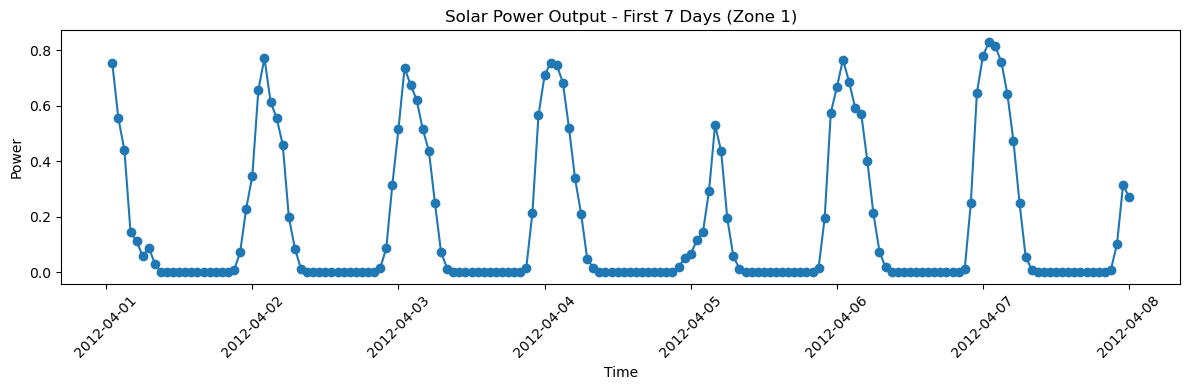

In [4]:
import matplotlib.pyplot as plt

# Take only the first 7 days (24 hours * 7)
subset = train.iloc[:24*7]

plt.figure(figsize=(12, 4))
plt.plot(subset['TIMESTAMP'], subset['POWER'], marker='o')
plt.title("Solar Power Output - First 7 Days (Zone 1)")
plt.xlabel("Time")
plt.ylabel("Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("first7days.png", dpi=300)   # ⭐ 保存图片
plt.show()


In [5]:
predictors = pd.read_csv("Solar/Task 1/predictors1.csv")

# Convert TIMESTAMP to datetime
predictors['TIMESTAMP'] = pd.to_datetime(predictors['TIMESTAMP'], format='%Y%m%d %H:%M')

# Merge train and predictors on TIMESTAMP and ZONEID
df = pd.merge(train, predictors, on=['ZONEID', 'TIMESTAMP'], how='inner')

# Optional: drop ZONEID if only one zone
df = df.drop(columns=['ZONEID'])
df.head()


,TIMESTAMP,POWER,hour,day,month,year,VAR78,VAR79,VAR134,VAR157,VAR164,VAR165,VAR166,VAR167,VAR169,VAR175,VAR178,VAR228
0,2012-04-01 01:00:00,0.754103,1,1,4,2012,0.001967,0.003609,94843.6250,60.221909,0.244601,1.039334,-2.503039,294.448486,2577830.0,1202532.0,2861797.0,0.000000
1,2012-04-01 02:00:00,0.555000,2,1,4,2012,0.005524,0.033575,94757.9375,54.678604,0.457138,2.482865,-2.993330,295.651367,5356093.0,2446757.0,5949378.0,0.000000
2,2012-04-01 03:00:00,0.438397,3,1,4,2012,0.030113,0.132009,94732.8125,61.294891,0.771429,3.339867,-1.982535,294.454590,7921788.0,3681336.0,8939176.0,0.001341
3,2012-04-01 04:00:00,0.145449,4,1,4,2012,0.057167,0.110645,94704.0625,67.775284,0.965866,3.106102,-1.446051,293.261475,9860520.0,4921504.0,11331679.0,0.002501
4,2012-04-01 05:00:00,0.111987,5,1,4,2012,0.051027,0.189560,94675.0000,70.172989,0.944669,2.601146,-1.904493,292.732910,11143097.0,6254380.0,13105558.0,0.003331


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load train and predictors
train = pd.read_csv("Solar/Task 1/train1.csv")
predictors = pd.read_csv("Solar/Task 1/predictors1.csv")

# Convert timestamp
train['TIMESTAMP'] = pd.to_datetime(train['TIMESTAMP'], format='%Y%m%d %H:%M')
predictors['TIMESTAMP'] = pd.to_datetime(predictors['TIMESTAMP'], format='%Y%m%d %H:%M')

# Merge on TIMESTAMP and ZONEID
df = pd.merge(train, predictors, on=['ZONEID', 'TIMESTAMP'], how='inner')
df = df.drop(columns=['ZONEID'])

# Normalize features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['TIMESTAMP']))

# Create sequences
def create_sequences(data, target_col=-1, seq_len=24):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, :])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, target_col=-1, seq_len=24)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Split into train/test
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Create DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
import torch.nn as nn

class SolarLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(SolarLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # Take the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out

input_size = X_train.shape[2]
model = SolarLSTM(input_size)

In [8]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20  # start small for speed

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.6f}")

Epoch 1/20, Loss: 0.002044
Epoch 2/20, Loss: 0.000838
Epoch 3/20, Loss: 0.000691
Epoch 4/20, Loss: 0.000607
Epoch 5/20, Loss: 0.000564
Epoch 6/20, Loss: 0.000533
Epoch 7/20, Loss: 0.000515
Epoch 8/20, Loss: 0.000486
Epoch 9/20, Loss: 0.000487
Epoch 10/20, Loss: 0.000474
Epoch 11/20, Loss: 0.000442
Epoch 12/20, Loss: 0.000455
Epoch 13/20, Loss: 0.000439
Epoch 14/20, Loss: 0.000399
Epoch 15/20, Loss: 0.000425
Epoch 16/20, Loss: 0.000379
Epoch 17/20, Loss: 0.000410
Epoch 18/20, Loss: 0.000391
Epoch 19/20, Loss: 0.000397
Epoch 20/20, Loss: 0.000450


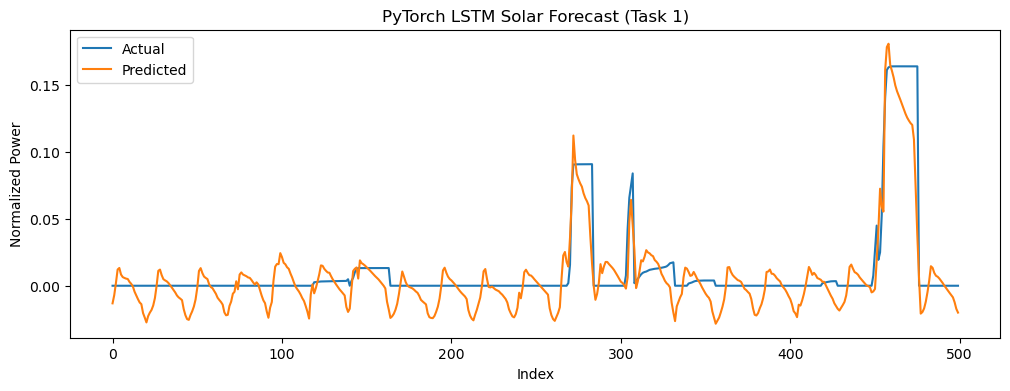

Saved figure as lstm_task1_prediction.png


In [9]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

plt.figure(figsize=(12, 4))
plt.plot(y_test.numpy()[:500], label='Actual')
plt.plot(y_pred[:500], label='Predicted')
plt.legend()
plt.title("PyTorch LSTM Solar Forecast (Task 1)")
plt.xlabel("Index")
plt.ylabel("Normalized Power")

# 保存图片（推荐 PNG 格式）
plt.savefig("lstm_task1_prediction.png", dpi=300, bbox_inches='tight')

plt.show()

print("Saved figure as lstm_task1_prediction.png")


In [10]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test.numpy(), y_pred)
print("MAE:", mae)

MAE: 0.015101843513548374


In [11]:
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler

# Load predictors
predictors = pd.read_csv("Solar/Task 1/predictors1.csv")
predictors['TIMESTAMP'] = pd.to_datetime(predictors['TIMESTAMP'], format='%Y%m%d %H:%M')

# Drop non-numeric columns for model input
X_pred_df = predictors.drop(columns=['ZONEID', 'TIMESTAMP'])

# Convert to float
X_pred_df = X_pred_df.astype(float)

# Optionally: scale using the same scaler used on training
# (Important! Use the fitted scaler from training, not a new one)
# scaler = MinMaxScaler()
# X_pred_scaled = scaler.fit_transform(X_pred_df)
X_pred_scaled = X_pred_df.values  # If you want raw values

# Convert to PyTorch tensor
X_pred = torch.tensor(X_pred_scaled, dtype=torch.float32)

# Ensure LSTM shape: (samples, time_steps, features)
# For example, using seq_len=24 like in training:
seq_len = 24
X_seq = []
for i in range(seq_len, len(X_pred)):
    X_seq.append(X_pred[i-seq_len:i, :])
X_seq = torch.stack(X_seq)  # shape: (num_samples, seq_len, num_features)

print("Prepared X_seq shape:", X_seq.shape)

Prepared X_seq shape: torch.Size([28416, 24, 12])


In [12]:
# Columns used as features
feature_cols = df.drop(columns=['TIMESTAMP', 'POWER']).columns

# Fit scaler only on features
scaler_features = MinMaxScaler()
scaler_features.fit(df[feature_cols].values)

# Scale training data
scaled_features = scaler_features.transform(df[feature_cols].values)

# Append target (POWER) as last column for sequences
scaled_data = np.hstack([scaled_features, df['POWER'].values.reshape(-1, 1)])

# --- Then create sequences as before ---
seq_len = 24
X, y = create_sequences(scaled_data, target_col=-1, seq_len=seq_len)

In [13]:
# 1️⃣ Load future predictor data
future_preds = pd.read_csv("Solar/Task 1/predictors1.csv")

# Convert TIMESTAMP
future_preds['TIMESTAMP'] = pd.to_datetime(future_preds['TIMESTAMP'], format='%Y%m%d %H:%M')

# Drop ZONEID if only one zone
future_preds = future_preds.drop(columns=['ZONEID'])

In [14]:
# Drop TIMESTAMP and convert to float
future_features = future_preds.drop(columns=['TIMESTAMP']).values.astype(np.float32)

# Scale using the feature-only scaler
future_scaled_features = scaler_features.transform(future_features)

# Add dummy target column to match sequence creation
dummy_target = np.zeros((future_scaled_features.shape[0], 1), dtype=np.float32)
future_scaled = np.hstack([future_scaled_features, dummy_target])

# Create sequences for LSTM
seq_len = 24
X_seq = []
for i in range(seq_len, len(future_scaled)):
    X_seq.append(future_scaled[i-seq_len:i, :])
X_seq = np.array(X_seq)

# Convert to PyTorch tensor
X_seq = torch.tensor(X_seq, dtype=torch.float32)

# Predict
model.eval()
with torch.no_grad():
    y_future = model(X_seq).numpy()


In [15]:
print(X_seq.shape)  # (num_samples, seq_len, num_features)
print(y_future.shape)  # (num_samples, 1)

torch.Size([28416, 24, 13])
(28416, 1)


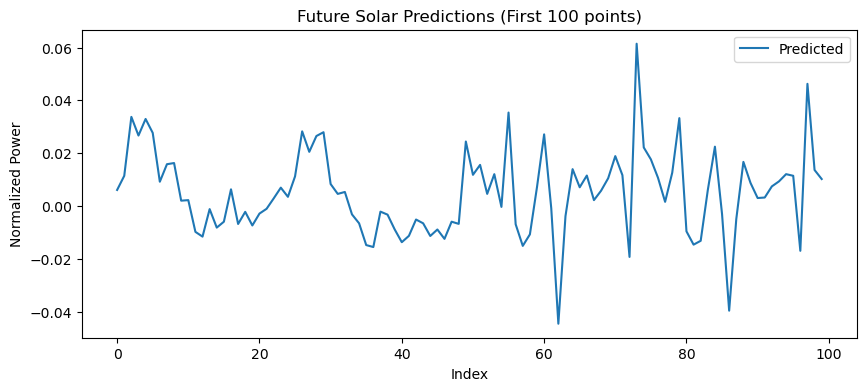

Saved figure as future_solar_predictions.png


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_future[:100], label='Predicted')
plt.title("Future Solar Predictions (First 100 points)")
plt.xlabel("Index")
plt.ylabel("Normalized Power")
plt.legend()

# 保存图片
plt.savefig("future_solar_predictions.png", dpi=300, bbox_inches='tight')

plt.show()

print("Saved figure as future_solar_predictions.png")


In [17]:
from sklearn.metrics import mean_absolute_error

# Example: compare first 100 predictions with actual if available
actual = train['POWER'].values[-100:]
mae = mean_absolute_error(actual, y_future[:100])
print("MAE vs actual last 100 points:", mae)

MAE vs actual last 100 points: 0.20260733735990524


In [18]:
# Only scale the last column (target)
y_future_real = scaler.inverse_transform(
    np.hstack([np.zeros((y_future.shape[0], X_seq.shape[2]-1)), y_future])
)[:, -1]

In [19]:
# --- Predict Future Quantiles for GEFCom2014 Submission ---
import pandas as pd
import numpy as np
import torch

# Load the future predictor data
future_preds = pd.read_csv("Solar/Task 1/predictors1.csv")
future_preds['TIMESTAMP'] = pd.to_datetime(future_preds['TIMESTAMP'], format='%Y%m%d %H:%M')

# Drop only columns that are not features
future_features = future_preds.drop(columns=['ZONEID', 'TIMESTAMP']).values.astype(np.float32)

# Make sure the number of features matches training
print("Number of features for prediction:", future_features.shape[1])
print("Number of features model expects:", input_size)

# Scale features using the same scaler as training (feature-only)
scaler_features = MinMaxScaler()
scaler_features.fit(df.drop(columns=['TIMESTAMP', 'POWER']))  # only features
future_scaled = scaler_features.transform(future_features)

# Create sequences (use last seq_len rows for first sequence)
seq_len = 24
X_future = []
for i in range(seq_len, len(future_scaled)+1):
    X_future.append(future_scaled[i-seq_len:i, :])
X_future = np.array(X_future, dtype=np.float32)
X_future = torch.tensor(X_future, dtype=torch.float32)

model.eval()
with torch.no_grad():
    # Predict mean values
    y_mean = model(X_future).numpy().flatten()

# Simple way to get quantiles: assume small Gaussian noise based on training residuals
residuals = y_train.numpy().flatten() - model(X_train).detach().numpy().flatten()
sigma = np.std(residuals)
quantiles = np.arange(0.01, 1.0, 0.01)

# Build quantile forecast
y_quantiles = []
for q in quantiles:
    z = np.quantile(np.random.normal(0, sigma, 1000), q)  # approximate quantile offset
    y_quantiles.append(y_mean + z)

y_quantiles = np.array(y_quantiles).T  # shape: samples x quantiles

# Construct DataFrame in benchmark format
df_submission = pd.DataFrame({
    'ZONEID': future_preds['ZONEID'].iloc[seq_len-1:].values,
    'TIMESTAMP': future_preds['TIMESTAMP'].iloc[seq_len-1:].values
})
for i, q in enumerate(quantiles):
    df_submission[f"{q:.2f}"] = y_quantiles[:, i]

# Save CSV for submission
df_submission.to_csv("Solar/Task 1/prediction_quantiles.csv", index=False)
print("Prediction saved to prediction_quantiles.csv")

Number of features for prediction: 12
Number of features model expects: 13


/home/yanghao/anaconda3/envs/gefcom/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


RuntimeError: input.size(-1) must be equal to input_size. Expected 13, got 12